<a href="https://colab.research.google.com/github/MidhunPY/Used-Car-Price-Prediction-using-Machine-Learning/blob/main/project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv("cardekho_imputated.csv")
df.sample(5)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
14959,18970,Maruti Alto,Maruti,Alto,7,30000,Individual,Petrol,Manual,23.95,998,67.05,5,250000
10033,12831,Honda City,Honda,City,9,69000,Dealer,Petrol,Manual,16.80,1497,116.40,5,390000
2049,2630,Hyundai Verna,Hyundai,Verna,4,49000,Dealer,Diesel,Automatic,22.00,1582,126.20,5,1120000
12801,16228,BMW 5,BMW,5,3,23000,Dealer,Diesel,Automatic,18.59,2993,261.49,5,5150000
13400,17009,BMW 5,BMW,5,12,70000,Dealer,Diesel,Automatic,11.50,2993,235.00,5,695000


In [ ]:
df.shape

(15411, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [ ]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [ ]:
df=df.drop(columns=["Unnamed: 0"])
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0
engine,0


In [ ]:
df.columns = df.columns.str.strip()
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
df.duplicated().sum()

np.int64(167)

In [ ]:
df[df.duplicated(keep=False)].sort_values("car_name").head(10)

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
10098,Audi A4,Audi,A4,5,51000,Dealer,Diesel,Automatic,18.25,1968,187.74,5,1850000
10492,Audi A4,Audi,A4,5,51000,Dealer,Diesel,Automatic,18.25,1968,187.74,5,1850000
3585,Audi A4,Audi,A4,9,68370,Dealer,Diesel,Automatic,17.11,1968,174.33,5,1345000
13469,Audi A4,Audi,A4,9,68370,Dealer,Diesel,Automatic,17.11,1968,174.33,5,1345000
10315,BMW 5,BMW,5,0,2000,Dealer,Diesel,Automatic,22.48,1995,187.74,5,4850000
11486,BMW 5,BMW,5,0,2000,Dealer,Diesel,Automatic,22.48,1995,187.74,5,4850000
12665,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993,261.40,4,5600000
14683,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993,261.40,4,5600000
10750,BMW 7,BMW,7,13,70000,Dealer,Petrol,Automatic,8.45,2979,321.00,5,750000
973,BMW 7,BMW,7,13,70000,Dealer,Petrol,Automatic,8.45,2979,321.00,5,750000


In [ ]:
df=df.drop_duplicates()
df.shape

(15244, 13)

In [ ]:
df.reset_index(drop=True,inplace=True)
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
a=["brand","model","car_name"]
for i in a:
  print(f"{i} : {df[i].nunique()}")

brand : 32
model : 120
car_name : 121


In [ ]:
df=df.drop(columns=["model","brand"])
df.head()

,car_name,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


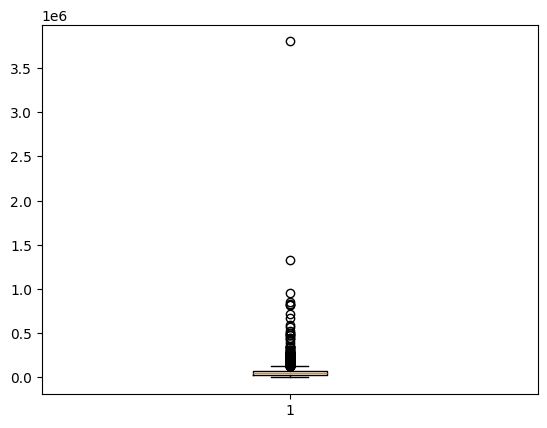

In [ ]:
plt.boxplot(df["km_driven"])
plt.show()

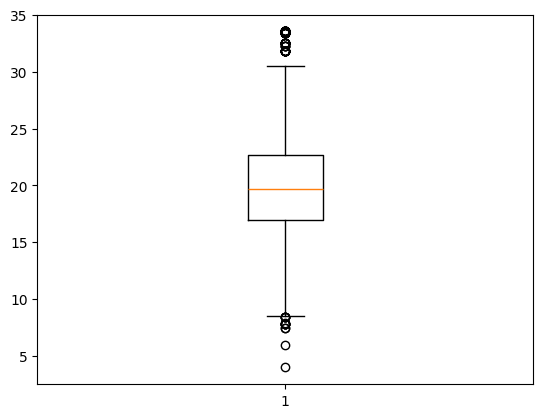

In [ ]:
plt.boxplot(df["mileage"])
plt.show()

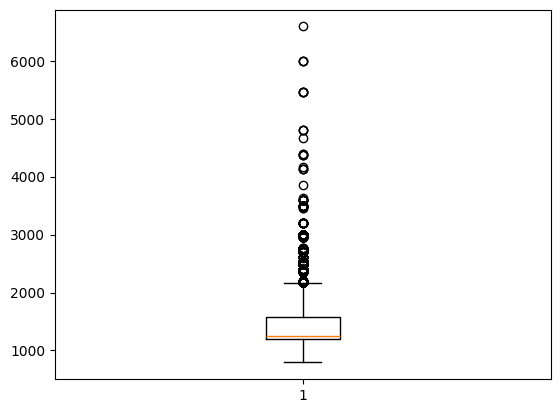

In [ ]:
plt.boxplot(df["engine"])
plt.show()

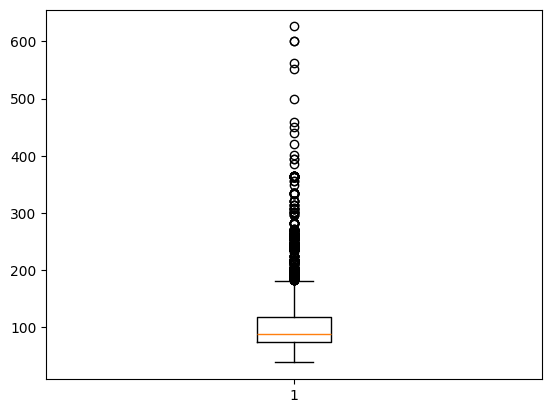

In [ ]:
plt.boxplot(df["max_power"])
plt.show()

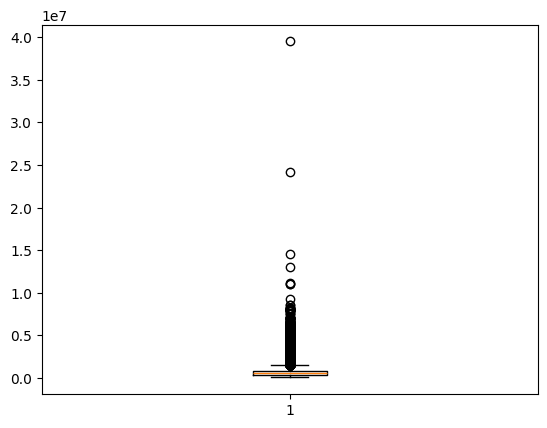

In [ ]:
plt.boxplot(df["selling_price"])
plt.show()

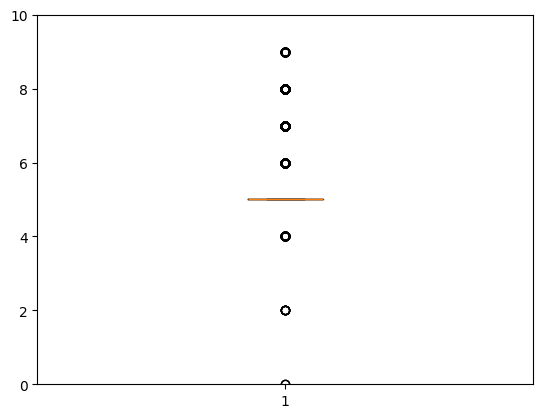

In [ ]:
plt.boxplot(df['seats'])
plt.ylim(0, 10)
plt.show()

In [ ]:
df[df["km_driven"]>1000000]

,car_name,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
11790,Mercedes-Benz E-Class,9,1325000,Dealer,Diesel,Automatic,11.5,2987,210.0,5,1350000
15242,Mahindra XUV500,5,3800000,Dealer,Diesel,Manual,16.0,2179,140.0,7,1225000


In [ ]:
df=df[df["km_driven"]<1000000]
df.shape

(15242, 11)

In [ ]:
df.reset_index(drop=True,inplace=True)
df.head()

,car_name,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


## **EDA** -* Exploratory Data Analysis*

<Axes: xlabel='selling_price', ylabel='Density'>

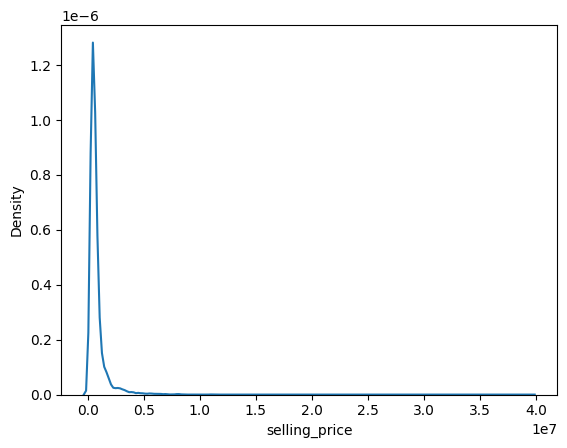

In [ ]:
sns.kdeplot(x=df['selling_price'])

In [ ]:
df["log_sp"]=np.log1p(df["selling_price"])
df.head()

,car_name,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,log_sp
0,Maruti Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000,11.695255
1,Hyundai Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000,13.217675
2,Hyundai i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000,12.278398
3,Maruti Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000,12.328295
4,Ford Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000,13.253393


## **Numerical vs Target**

### KM_DRIVEN VS SELLING_PRICE

<Axes: xlabel='km_driven', ylabel='selling_price'>

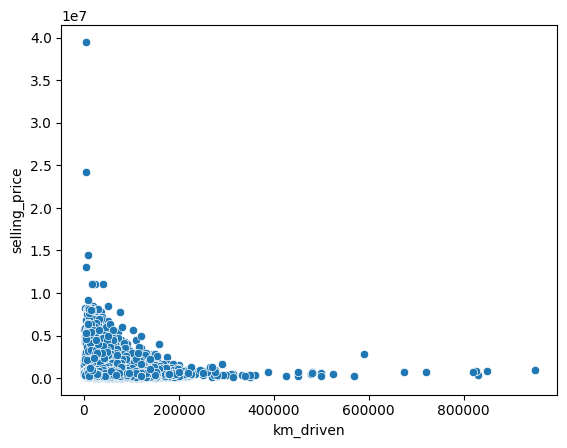

In [ ]:
sns.scatterplot(x=df["km_driven"], y=df["selling_price"])

<Axes: xlabel='km_driven', ylabel='log_sp'>

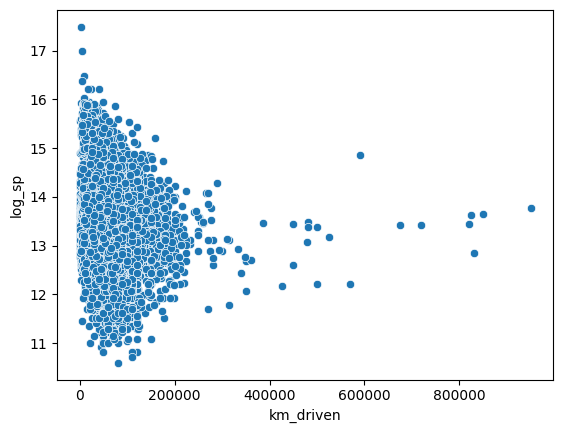

In [ ]:
sns.scatterplot(x=df["km_driven"], y=df["log_sp"])

### MILEAGE VS SELLING_PRICE

<Axes: xlabel='mileage', ylabel='selling_price'>

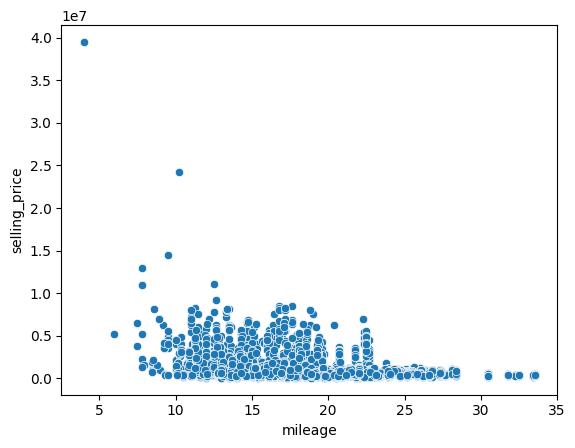

In [ ]:
sns.scatterplot(x=df["mileage"],y=df["selling_price"])

<Axes: xlabel='mileage', ylabel='log_sp'>

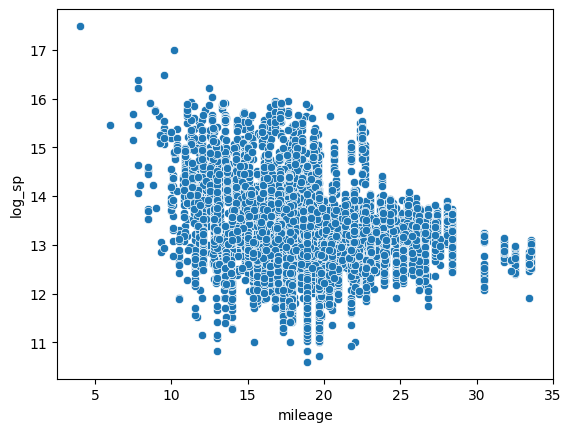

In [ ]:
sns.scatterplot(x=df["mileage"],y=df["log_sp"])

### ENGINE VS SELLING_PRICE

(500.0, 7000.0)

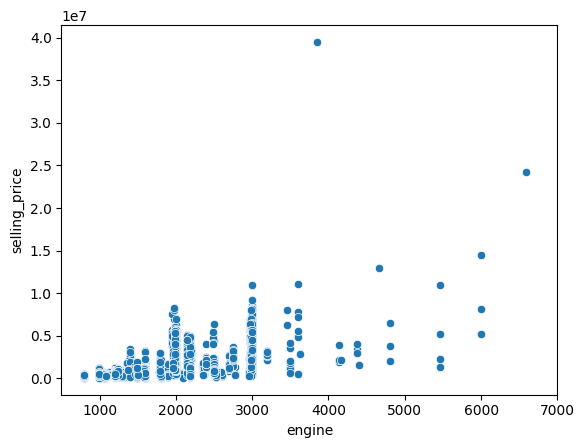

In [ ]:
sns.scatterplot(x=df["engine"],y=df["selling_price"])
plt.xlim(500,7000)

<Axes: xlabel='engine', ylabel='log_sp'>

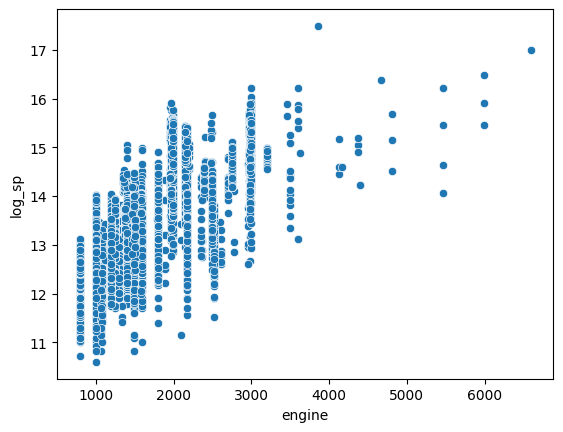

In [ ]:
sns.scatterplot(x=df["engine"],y=df["log_sp"])

### MAX_POWER VS SELLING_PRICE

(30.0, 700.0)

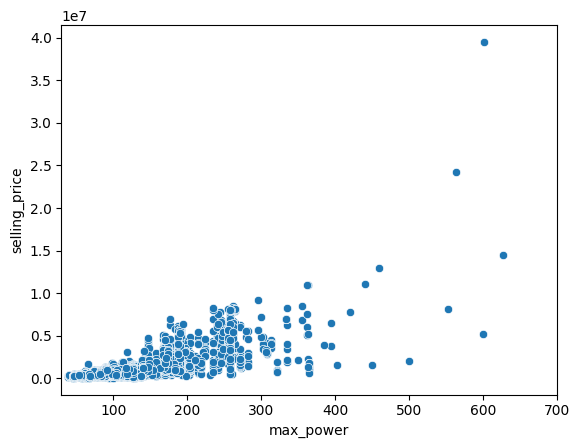

In [ ]:
sns.scatterplot(x=df["max_power"],y=df["selling_price"])
plt.xlim(30,700)

<Axes: xlabel='max_power', ylabel='log_sp'>

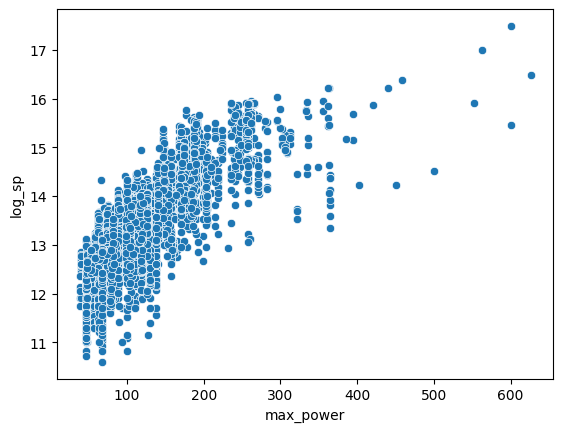

In [ ]:
sns.scatterplot(x=df["max_power"],y=df["log_sp"])

### SEATS VS SELLING_PRICE

(0.0, 10.0)

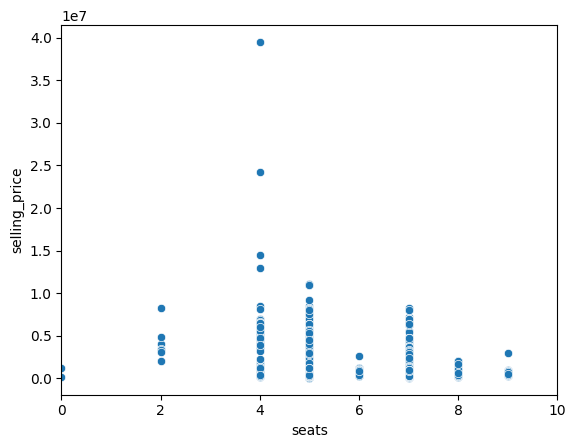

In [ ]:
sns.scatterplot(x=df["seats"],y=df["selling_price"])
plt.xlim(0,10)

<Axes: xlabel='seats', ylabel='log_sp'>

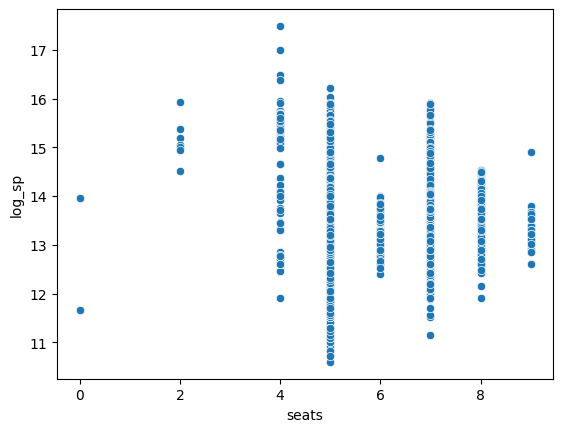

In [ ]:
sns.scatterplot(x=df["seats"],y=df["log_sp"])

## **Categorical Vs Target**

## CarName vs SellingPrice

<Axes: xlabel='car_name', ylabel='selling_price'>

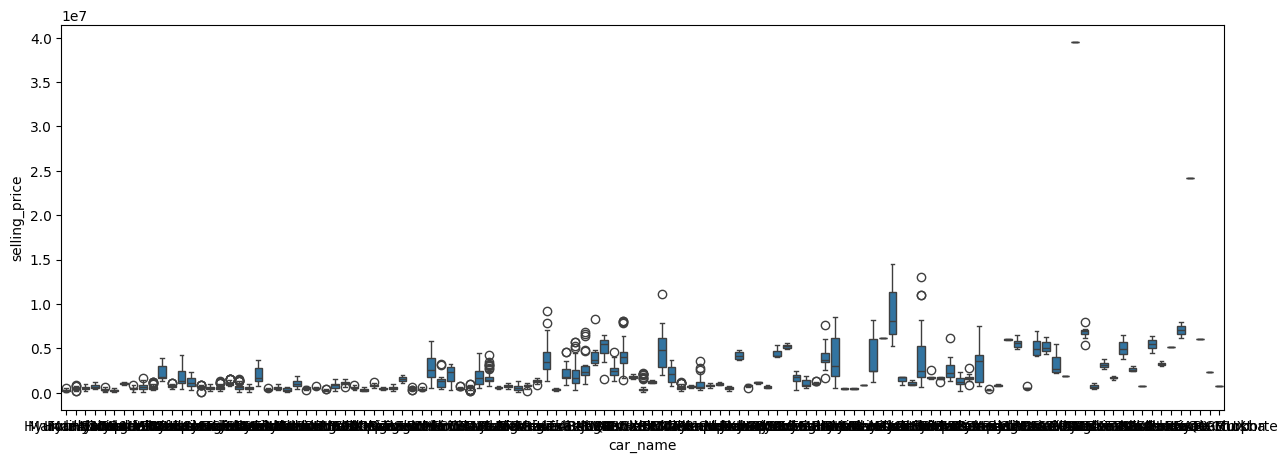

In [ ]:
plt.figure(figsize=(15,5))
sns.boxplot(x=df["car_name"],y=df["selling_price"])


<Axes: xlabel='car_name', ylabel='selling_price'>

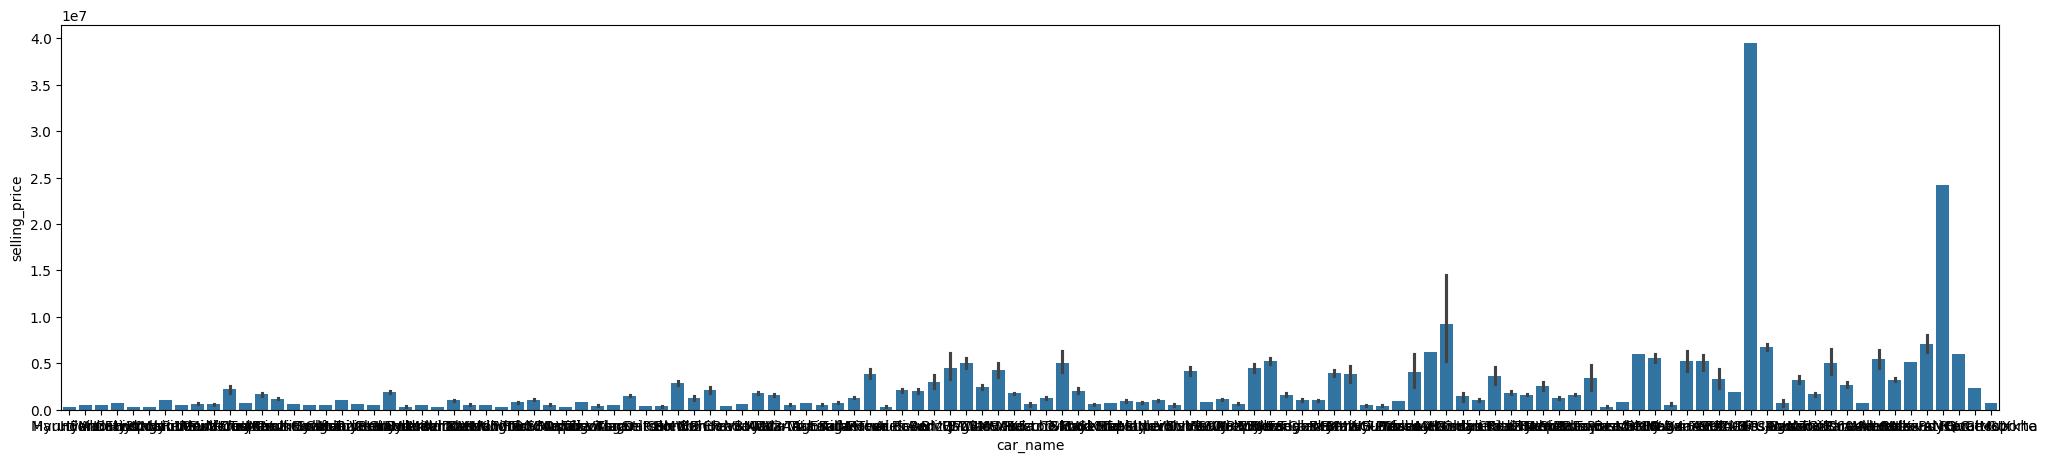

In [ ]:
plt.figure(figsize=(25,5))
sns.barplot(x=df["car_name"],y=df["selling_price"])

## Fuel_type vs Selling_Price

<Axes: xlabel='fuel_type', ylabel='selling_price'>

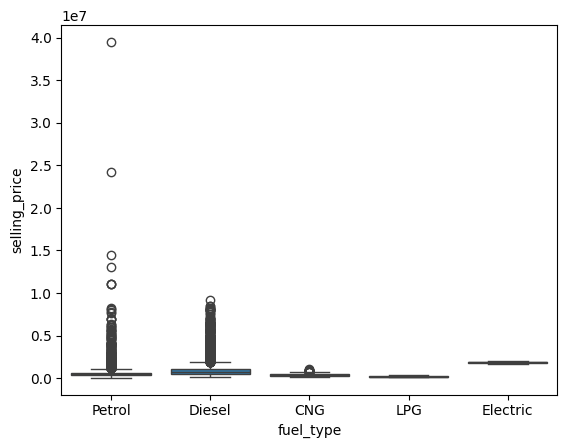

In [ ]:
sns.boxplot(x=df["fuel_type"],y=df["selling_price"])

<Axes: xlabel='fuel_type', ylabel='selling_price'>

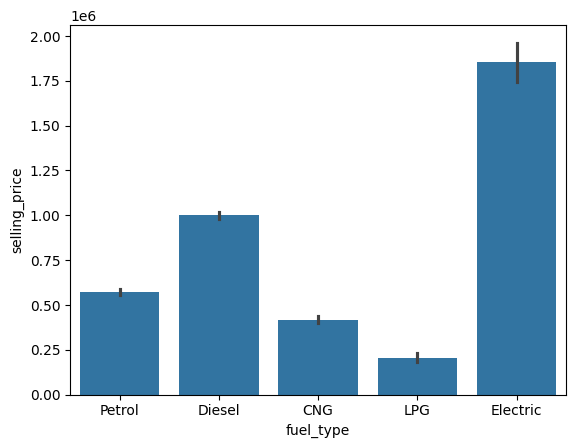

In [ ]:
sns.barplot(x=df["fuel_type"],y=df["selling_price"])

## Seller_Type vs Selling_Price

<Axes: xlabel='seller_type', ylabel='selling_price'>

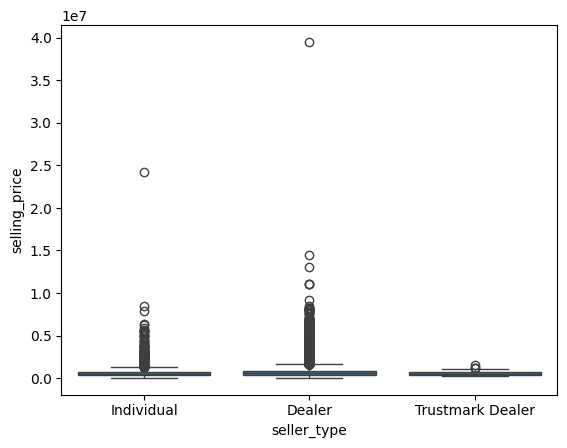

In [ ]:
sns.boxplot(x=df["seller_type"],y=df["selling_price"])

<Axes: xlabel='seller_type', ylabel='selling_price'>

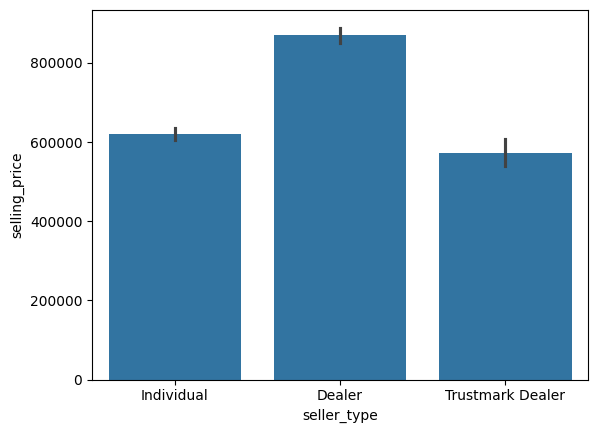

In [ ]:
sns.barplot(x=df["seller_type"],y=df["selling_price"])

## Transmission_Type vs Selling_Price

<Axes: xlabel='transmission_type', ylabel='selling_price'>

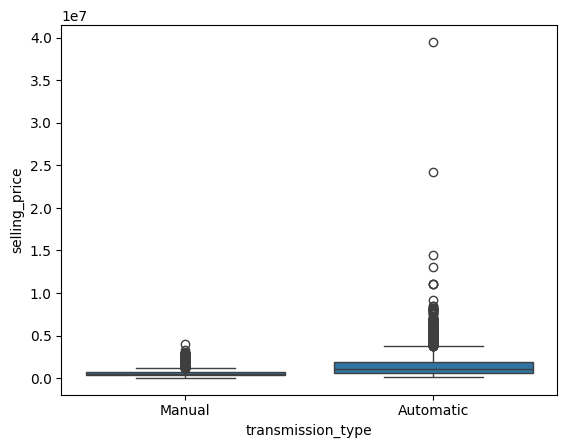

In [ ]:
sns.boxplot(x=df['transmission_type'],y=df['selling_price'])

<Axes: xlabel='transmission_type', ylabel='selling_price'>

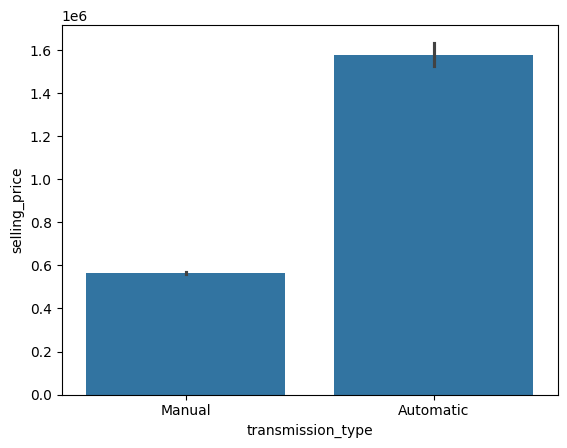

In [ ]:
sns.barplot(x=df['transmission_type'],y=df['selling_price'])

In [ ]:
df=df.drop(columns=["selling_price"])
df.head()

,car_name,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,log_sp
0,Maruti Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,11.695255
1,Hyundai Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,13.217675
2,Hyundai i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,12.278398
3,Maruti Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,12.328295
4,Ford Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,13.253393


## **Encoding**

In [ ]:
enc_values=["fuel_type","seller_type","transmission_type","car_name"]
encoder=OneHotEncoder(drop='first',sparse_output=False)
Onehot_enc=encoder.fit_transform(df[enc_values])
fuel_encoding=pd.DataFrame(Onehot_enc,columns=encoder.get_feature_names_out(enc_values))
df=pd.concat([df,fuel_encoding],axis=1)
df.head()

,car_name,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,...,car_name_Toyota Fortuner,car_name_Toyota Glanza,car_name_Toyota Innova,car_name_Toyota Yaris,car_name_Volkswagen Polo,car_name_Volkswagen Vento,car_name_Volvo S90,car_name_Volvo XC,car_name_Volvo XC60,car_name_Volvo XC90
0,Maruti Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Hyundai Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Hyundai i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Maruti Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Ford Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
col=["seller_type","fuel_type","transmission_type","car_name"]
df=df.drop(columns=col)
df.head()

,vehicle_age,km_driven,mileage,engine,max_power,seats,log_sp,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,...,car_name_Toyota Fortuner,car_name_Toyota Glanza,car_name_Toyota Innova,car_name_Toyota Yaris,car_name_Volkswagen Polo,car_name_Volkswagen Vento,car_name_Volvo S90,car_name_Volvo XC,car_name_Volvo XC60,car_name_Volvo XC90
0,9,120000,19.70,796,46.30,5,11.695255,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5,20000,18.90,1197,82.00,5,13.217675,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,11,60000,17.00,1197,80.00,5,12.278398,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,9,37000,20.92,998,67.10,5,12.328295,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6,30000,22.77,1498,98.59,5,13.253393,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## **Splitting Data**

In [ ]:
X=df.drop(columns=["log_sp"])
y=df["log_sp"]
print(X.shape)
print(y.shape)

(15242, 133)
(15242,)


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12193, 133)
(3049, 133)
(12193,)
(3049,)


## **Feature Scaling**

In [ ]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(X_train)
x_test_scaled=scaler.transform(X_test)

## **Training**

In [ ]:
model=LinearRegression()
model.fit(x_train_scaled,y_train)

LinearRegression()

In [ ]:
model.coef_
model.intercept_

np.float64(13.27945223759319)

## **PREDICTION**

In [ ]:
y_pred=model.predict(x_test_scaled)

## **Evalution**

In [ ]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

0.14008242890963687
0.03392735972975543
0.18419381023735684
0.9242285920813345


In [ ]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

In [ ]:
mae=mean_absolute_error(y_test_actual,y_pred_actual)
mse=mean_squared_error(y_test_actual,y_pred_actual)
rmse=np.sqrt(mse)
r2=r2_score(y_test_actual,y_pred_actual)

print(mae)
print(mse)
print(rmse)
print(r2)

109529.25003356823
66144472486.94951
257185.67706415828
0.8897670330735539


## **Hyperparameter Tunning**

In [ ]:
alpha=[0.01,0.1,1,10,100]
ridge_cv=RidgeCV(alphas=alpha,cv=5)
ridge_cv.fit(x_train_scaled,y_train)
y_pred_ridge=ridge_cv.predict(x_test_scaled)

In [ ]:
mae=mean_absolute_error(y_test,y_pred_ridge)
mse=mean_squared_error(y_test,y_pred_ridge)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_ridge)

print(mae)
print(mse)
print(rmse)
print(r2)

0.14005000377165006
0.03390306918411833
0.18412786096655318
0.9242828411846157


In [ ]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_ridge)

In [ ]:
mae=mean_absolute_error(y_test_actual,y_pred_actual)
mse=mean_squared_error(y_test_actual,y_pred_actual)
rmse=np.sqrt(mse)
r2=r2_score(y_test_actual,y_pred_actual)

print(mae)
print(mse)
print(rmse)
print(r2)

109508.35211409476
66182690419.98399
257259.96660962232
0.8897033410371706


## **Lasso Cross-Validation**

In [ ]:
alpha= np.logspace(-4, 2, 50)
lasso_cv=LassoCV(alphas=alpha,cv=5,max_iter=10000)
lasso_cv.fit(x_train_scaled,y_train)
y_pred_lasso=lasso_cv.predict(x_test_scaled)


In [ ]:
mae=mean_absolute_error(y_test,y_pred_lasso)
mse=mean_squared_error(y_test,y_pred_lasso)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_lasso)

print(mae)
print(mse)
print(rmse)
print(r2)

0.13994284380578056
0.033775400360840584
0.1837808487325069
0.9245679693691878


In [ ]:
y_pred_actual=np.expm1(y_pred_lasso)
y_test_actual=np.expm1(y_test)

In [ ]:
mae=mean_absolute_error(y_test_actual,y_pred_actual)
mse=mean_squared_error(y_test_actual,y_pred_actual)
rmse=np.sqrt(mse)
r2=r2_score(y_test_actual,y_pred_actual)

print(mae)
print(mse)
print(rmse)
print(r2)

109685.6418563909
66680883823.96996
258226.41968623188
0.8888730776007906


In [ ]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "lasso_coef": lasso_cv.coef_
})
print("Zero coefficients:", (coef_df["lasso_coef"] == 0).sum())

coef_df[coef_df["lasso_coef"] == 0]

Zero coefficients: 2


,feature,lasso_coef
81,car_name_Maruti Dzire LXI,0.0
94,car_name_Maserati Quattroporte,0.0


## **RANDOMFOREST**

In [ ]:
rf=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

## **Training**

In [ ]:
rf.fit(x_train_scaled,y_train)

RandomForestRegressor(random_state=42)

## **Prediction**

In [ ]:
y_pred_rf=rf.predict(x_test_scaled)

## **Evaluation**

In [ ]:
mse=mean_squared_error(y_test,y_pred_rf)
mae=mean_absolute_error(y_test,y_pred_rf)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_rf)

print(mae)
print(mse)
print(rmse)
print(r2)

0.12994498665613563
0.0313721206825838
0.1771217679523999
0.9299353155551078


In [ ]:
y_test_actual_rf=np.expm1(y_test)
y_pred_actual_rf=np.expm1(y_pred_rf)

In [ ]:
mse=mean_squared_error(y_test_actual_rf,y_pred_actual_rf)
mae=mean_absolute_error(y_test_actual_rf,y_pred_actual_rf)
rmse=np.sqrt(mse)
r2=r2_score(y_test_actual_rf,y_pred_actual_rf)

print(mae)
print(mse)
print(rmse)
print(r2)

96760.15659204127
53314497111.26954
230899.3224573635
0.9111488084219549


In [ ]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance_df.sort_values(by="importance", ascending=False)

,feature,importance
4,max_power,6.357593e-01
0,vehicle_age,2.230824e-01
3,engine,4.432239e-02
1,km_driven,3.241859e-02
2,mileage,1.355956e-02
...,...,...
30,car_name_Force Gurkha,7.049385e-07
7,fuel_type_Electric,5.300580e-07
93,car_name_Maserati Ghibli,4.011290e-07
94,car_name_Maserati Quattroporte,0.000000e+00


In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [ ]:
best_rf = random_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print(r2_score(y_test, y_pred_rf))
print(r2_score(y_test_actual_rf,y_pred_actual_rf))

0.9333328396178346
0.9111488084219549


## **XGBOOST**

In [ ]:
xgb = XGBRegressor(random_state=42)

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring="r2",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

In [ ]:
best_xgb = random_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

In [ ]:
print(r2_score(y_test, y_pred_xgb))

0.9354749809639467


In [ ]:
y_test_actual_xgb=np.expm1(y_test)
y_pred_actual_xgb=np.expm1(y_pred_xgb)

In [ ]:
print(r2_score(y_test_actual_xgb, y_pred_actual_xgb))

0.9143101534270174
